# Set 12 - Zeitreihen darstellen und Fenster interaktiv auswählen

**Lernziele:** Einen Zeitindex prüfen, Bereiche klar darstellen, Auflösung und Fensterbreite unterscheiden und den Einfluss der Glättung sichtbar machen.

Wir starten mit 30 Tagen **synthetischer stündlicher Sensordaten**. Ein bekannter Trend, Tages-/Wochenmuster, korreliertes Rauschen und ein Niveauwechsel helfen beim Verstehen. Einheit: frei gewählte Sensoreinheiten (SE). Die Komponenten sind nur wegen der Simulation bekannt.

Die Kurs-PDF `ML_Set_01_04.pdf` erklärt auf Seite 24 den chronologischen Split. Hier beginnen wir davor: Was zeigt die Zeitachse, welches Fenster wird betrachtet und welche Information wäre zu einem Zeitpunkt überhaupt verfügbar?

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

kandidaten = [Path.cwd(), *Path.cwd().parents]
set_ordner = next((p for basis in kandidaten
                   for p in (basis, basis / "set12-zeitreihenanalyse")
                   if (p / "zeitreihen_tools.py").exists()), None)
if set_ordner is None:
    raise FileNotFoundError("Notebook bitte innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:
    sys.path.insert(0, str(set_ordner))
from zeitreihen_tools import (FARBEN, plot_stil, zeitachse, synthetische_reihe,
                              lag_tabelle, metriken, lade_bike, lade_energie)
plot_stil()

In [2]:
daten = synthetische_reihe()
y = daten.wert
print("Zeitraum:", y.index.min(), "bis", y.index.max())
print("Doppelte Zeitpunkte:", y.index.has_duplicates)
print("Zeitabstände:", y.index.to_series().diff().value_counts().to_dict())
display(daten.head().round(2))

Zeitraum: 2024-01-01 00:00:00 bis 2024-01-30 23:00:00
Doppelte Zeitpunkte: False
Zeitabstände: {Timedelta('0 days 01:00:00'): 719}


,wert,trend,saison,rauschen
zeit,,,,
2024-01-01 00:00:00,30.00,30.00,0.00,0.00
2024-01-01 01:00:00,29.93,30.02,1.37,-1.46
2024-01-01 02:00:00,32.94,30.04,2.65,0.25
2024-01-01 03:00:00,35.27,30.05,3.76,1.45
2024-01-01 04:00:00,32.77,30.07,4.63,-1.93


## 1. Übersicht und Detail statt einer überfüllten Grafik

Eine Zeitreihe braucht eine sortierte Zeitachse und eine bezeichnete Einheit. In einer Übersicht erkennen wir langfristige Veränderungen; im Detail einzelne Tagesmuster. Der farbige Bereich zeigt genau, welcher Ausschnitt unten zu sehen ist.

`iloc[120:337]` wählt Positionen 120 bis einschließlich 336. Ein Datumsausschnitt wie `loc["2024-01-06":"2024-01-14"]` wählt Zeitstempel. Die Grenzen von `loc` sind inklusive. Im Slider sind es ebenfalls inklusive Positionsgrenzen.

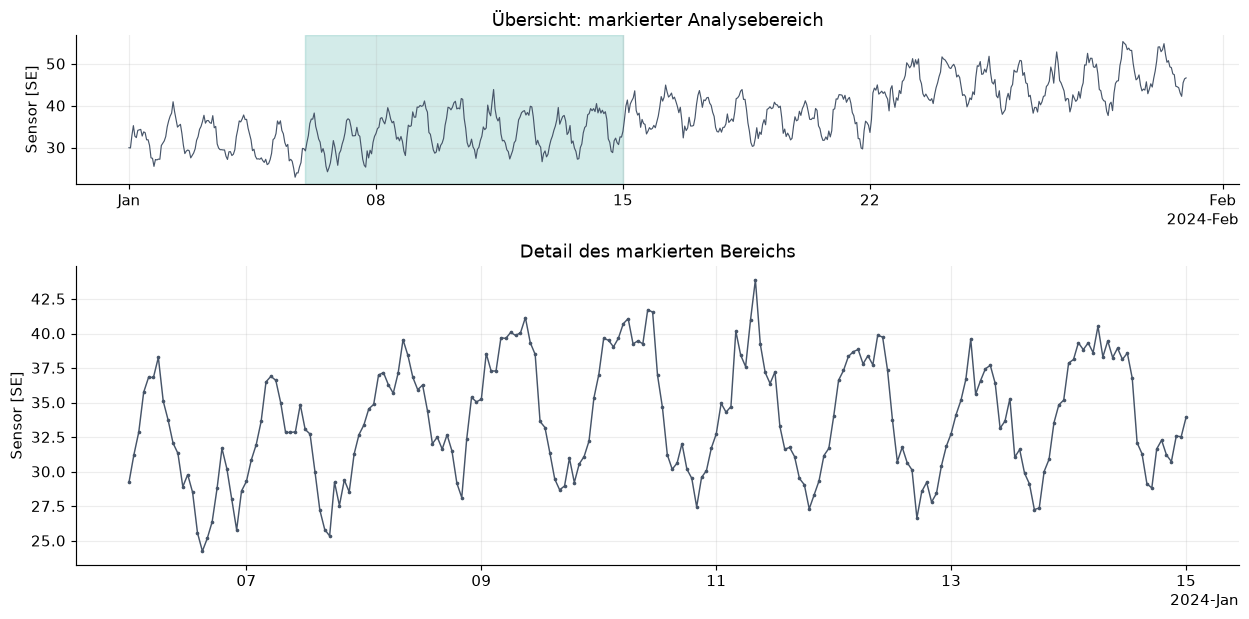

In [3]:
def zeige_bereich(start=120, ende=336):
    ausschnitt = y.iloc[start:ende + 1]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [1, 2]})
    axes[0].plot(y.index, y, color=FARBEN["roh"], lw=0.8)
    axes[0].axvspan(ausschnitt.index[0], ausschnitt.index[-1], color=FARBEN["saison"], alpha=0.18)
    axes[0].set(title="Übersicht: markierter Analysebereich", ylabel="Sensor [SE]")
    axes[1].plot(ausschnitt.index, ausschnitt, color=FARBEN["roh"], lw=1, marker=".", ms=3)
    axes[1].set(title="Detail des markierten Bereichs", ylabel="Sensor [SE]")
    for ax in axes: zeitachse(ax)
    plt.tight_layout(); plt.show()
zeige_bereich()

## 2. Drei verschiedene Breiten

- **Anzeige-/Analysebereich:** Welche Zeitpunkte sind im Detailplot sichtbar?
- **Abtastintervall:** Hier eine Stunde pro Messwert; es legt die zeitliche Auflösung fest.
- **Glättungsfenster:** Wie viele aufeinanderfolgende Messwerte gehen in den gleitenden Mittelwert ein?

24 Samples entsprechen hier 24 Stunden, bei 10-Minuten-Daten dagegen nur vier Stunden. Ein großes Fenster glättet stärker, verschmiert aber schnelle Veränderungen und kann Muster verdecken.

Beim nachlaufenden Fenster an Position `t` stammen die Werte aus `t-w+1` bis `t`. Ein zentriertes Fenster verwendet auch Werte nach `t` und eignet sich deshalb nur für nachträgliche Betrachtung. Für die **Vorhersage von y[t] vor seiner Beobachtung** muss sogar das nachlaufende Fenster noch mit `shift(1)` verschoben werden.

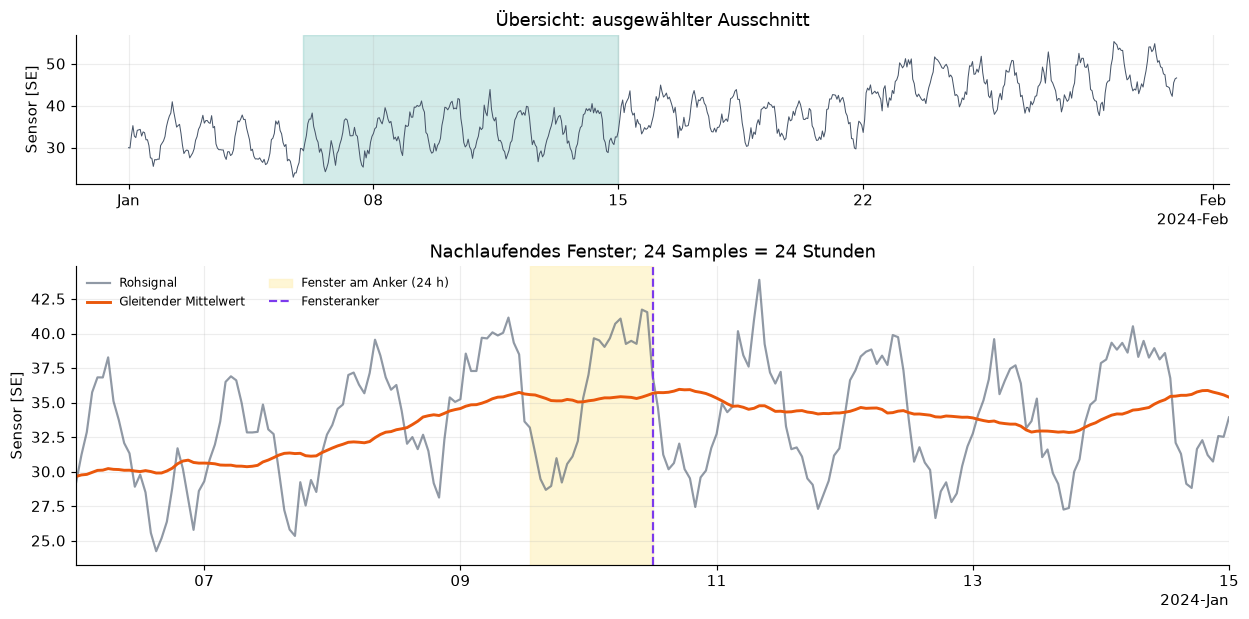

Ausschnitt: 217 Messpunkte; Mittelwert: 33.84 SE; Std: 4.20 SE
Das Glättungsfenster ist gelb markiert; Randwerte bleiben bei zu wenig Historie leer.


In [4]:
def zeige_fenster(bereich=(120, 336), breite=24, zentriert=False):
    links, rechts = bereich
    if rechts - links < 12:
        print("Bitte mindestens 13 Messpunkte auswählen.")
        return
    # Erst die gesamte verfügbare Reihe glätten, dann die Darstellung ausschneiden.
    glatt = y.rolling(breite, center=zentriert, min_periods=breite).mean()
    anker = (links + rechts) // 2
    if zentriert:
        fenster_start = anker - breite // 2
        fenster_ende = fenster_start + breite - 1
    else:
        fenster_start, fenster_ende = anker - breite + 1, anker
    a, b = max(0, fenster_start), min(len(y)-1, fenster_ende)
    teil = y.iloc[links:rechts + 1]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [1, 2]})
    axes[0].plot(y.index, y, color=FARBEN["roh"], lw=0.7)
    axes[0].axvspan(teil.index[0], teil.index[-1], color=FARBEN["saison"], alpha=0.18)
    axes[0].set(title="Übersicht: ausgewählter Ausschnitt", ylabel="Sensor [SE]")
    axes[1].plot(teil.index, teil, color=FARBEN["roh"], alpha=0.6, label="Rohsignal")
    axes[1].plot(teil.index, glatt.loc[teil.index], color=FARBEN["trend"], lw=2, label="Gleitender Mittelwert")
    axes[1].axvspan(y.index[a], y.index[b], color=FARBEN["val"], alpha=0.75, label=f"Fenster am Anker ({breite} h)")
    axes[1].axvline(y.index[anker], color=FARBEN["prognose"], ls="--", label="Fensteranker")
    if zentriert:
        axes[1].axvspan(y.index[anker], y.index[b], color=FARBEN["test"], alpha=0.6, label="Werte nach dem Anker")
    axes[1].set_xlim(teil.index[0], teil.index[-1])
    axes[1].set(title=f"{'Zentriertes' if zentriert else 'Nachlaufendes'} Fenster; {breite} Samples = {breite} Stunden", ylabel="Sensor [SE]")
    axes[1].legend(ncol=2, fontsize=8, loc="upper left")
    for ax in axes: zeitachse(ax)
    plt.tight_layout(); plt.show()
    print(f"Ausschnitt: {len(teil)} Messpunkte; Mittelwert: {teil.mean():.2f} SE; Std: {teil.std():.2f} SE")
    print("Das Glättungsfenster ist gelb markiert; Randwerte bleiben bei zu wenig Historie leer.")

# Gespeicherte statische Vorschau auch ohne laufenden Kernel.
zeige_fenster()

In [5]:
import ipywidgets as widgets
bereich_regler = widgets.IntRangeSlider(value=(120, 336), min=0, max=len(y)-1, step=1,
                                       description="Bereich", continuous_update=False,
                                       layout=widgets.Layout(width="750px"))
fenster_regler = widgets.IntSlider(value=24, min=3, max=168, step=1,
                                  description="Fenster [h]", continuous_update=False,
                                  layout=widgets.Layout(width="750px"))
zentrum_regler = widgets.Checkbox(value=False, description="Zentriert (nachträgliche Analyse)")
interaktiv = widgets.interactive_output(zeige_fenster,
    {"bereich": bereich_regler, "breite": fenster_regler, "zentriert": zentrum_regler})
display(widgets.VBox([bereich_regler, fenster_regler, zentrum_regler]), interaktiv)

Output()

**Experiment:** Wähle den Bereich um den Niveauwechsel bei Position 518. Vergleiche 6, 24 und 72 Stunden. Wie stark verzögert sich die Reaktion des nachlaufenden Mittelwerts? Wann beginnt ein zentriertes Fenster den Sprung schon vor seinem Auftreten zu zeigen?

Die gespeicherten Plots sind direkt lesbar. Zum Verändern der Regler die Zellen in JupyterLab mit laufendem Kernel ausführen; eine statische Notebook-Vorschau berechnet keine neuen Werte.

## 3. Resampling: neue Zeitauflösung ist etwas anderes als Glättung

`resample("6h").mean()` bildet je sechs Stunden einen neuen Mittelwert; die Zahl der Zeitpunkte wird kleiner. `rolling(6).mean()` bleibt auf dem ursprünglichen Stundenraster. Welche Aggregation passt, hängt von der Einheit ab: Temperatur mitteln, Energie je Intervall summieren.

Zeitstempel ohne Zeitzone sind hier eine bewusste Vereinfachung. Bei echten lokalen Uhrzeiten Sommerzeit, doppelte Stunden und fehlende Stunden vor `asfreq`/`resample` klären.

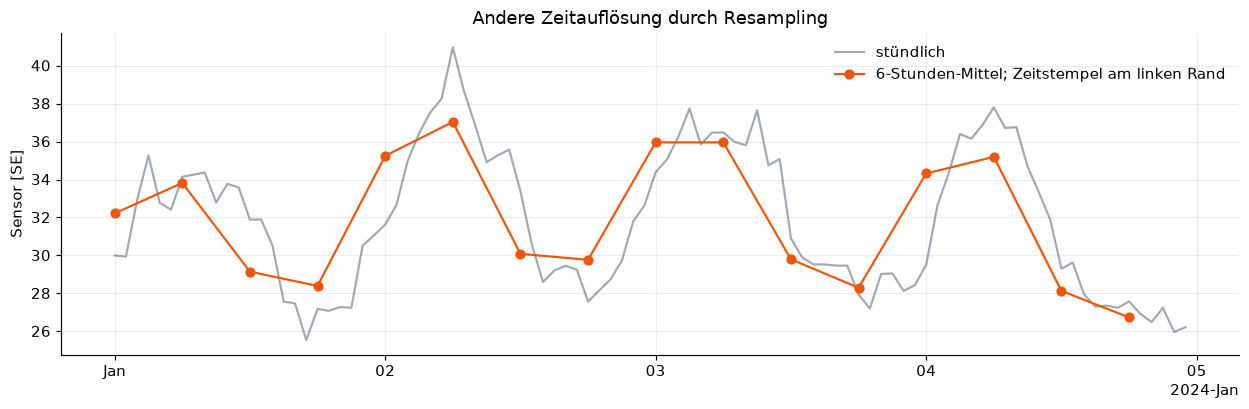

Original: 720 Werte; 6h-Raster: 120 Werte


In [6]:
grob = y.resample("6h", label="left", closed="left").mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y.iloc[:96], color=FARBEN["roh"], alpha=0.5, label="stündlich")
ax.plot(grob.iloc[:16], marker="o", color=FARBEN["trend"], label="6-Stunden-Mittel; Zeitstempel am linken Rand")
ax.set(ylabel="Sensor [SE]", title="Andere Zeitauflösung durch Resampling")
zeitachse(ax); ax.legend(); plt.tight_layout(); plt.show()
print("Original:", len(y), "Werte; 6h-Raster:", len(grob), "Werte")

## 4. Fehlende Zeitpunkte sichtbar machen

Eine entfernte Zeile ist nicht automatisch ein Nullwert. `asfreq` macht Lücken im erwarteten Raster als NaN sichtbar. Die rote Markierung zeigt die künstlich entfernte Stelle; die Verbindungslinie allein hätte die Lücke verdeckt.

Interpolation wäre eine Modellannahme. Eine beidseitige Interpolation kann einen späteren Wert verwenden und darf bei Prognosen nicht unbemerkt Zukunftsinformation liefern.

Fehlende Zeitpunkte: 6


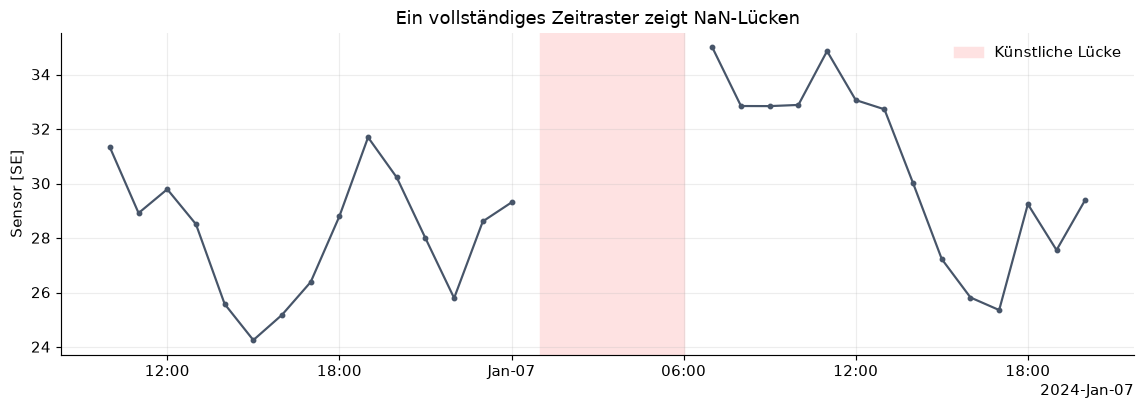

In [7]:
mit_luecke = y.drop(y.index[145:151]).asfreq("h")
print("Fehlende Zeitpunkte:", int(mit_luecke.isna().sum()))
fig, ax = plt.subplots()
ax.plot(mit_luecke.iloc[130:165], marker=".", color=FARBEN["roh"])
ax.axvspan(y.index[145], y.index[150], color=FARBEN["test"], label="Künstliche Lücke")
ax.set(ylabel="Sensor [SE]", title="Ein vollständiges Zeitraster zeigt NaN-Lücken")
zeitachse(ax); ax.legend(); plt.tight_layout(); plt.show()

## Kleine Aufgaben
1. Beschreibe Anzeige-, Abtast- und Glättungsfenster jeweils mit Einheit.
2. Wähle einen Bereich von zwei Tagen und teste Fenster von 6, 24 und 48 Stunden.
3. Weshalb beginnt eine geglättete Kurve am linken Rand manchmal später als das Rohsignal?
4. Formuliere den Unterschied zwischen nachträglicher Glättung und einem Merkmal zur Prognose von y[t].